In [1]:
!pip install pyspark

In [2]:
from google.colab import files

uploaded = files.upload()

Saving air_traffic_data.csv to air_traffic_data.csv


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
spark = SparkSession.builder \
    .appName("AirTrafficAnalysis") \
    .getOrCreate()

In [5]:
df = spark.read.csv(
    "air_traffic_data.csv",
    header=True,
    inferSchema=True
)


In [6]:
import pandas as pd

df.limit(20).toPandas()

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,Adjusted Activity Type Code,Adjusted Passenger Count,Year,Month
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
5,200507,Air China,CA,Air China,CA,International,Asia,Deplaned,Other,International,G,6263,Deplaned,6263,2005,July
6,200507,Air China,CA,Air China,CA,International,Asia,Enplaned,Other,International,G,5500,Enplaned,5500,2005,July
7,200507,Air France,AF,Air France,AF,International,Europe,Deplaned,Other,International,A,12050,Deplaned,12050,2005,July
8,200507,Air France,AF,Air France,AF,International,Europe,Enplaned,Other,International,A,11638,Enplaned,11638,2005,July
9,200507,Air New Zealand,NZ,Air New Zealand,NZ,International,Australia / Oceania,Deplaned,Other,International,G,4998,Deplaned,4998,2005,July


In [7]:
print("Number of Rows :", df.count())
print("Number of Columns :", len(df.columns))

df.printSchema()

Number of Rows : 15007
Number of Columns : 16
root
 |-- Activity Period: integer (nullable = true)
 |-- Operating Airline: string (nullable = true)
 |-- Operating Airline IATA Code: string (nullable = true)
 |-- Published Airline: string (nullable = true)
 |-- Published Airline IATA Code: string (nullable = true)
 |-- GEO Summary: string (nullable = true)
 |-- GEO Region: string (nullable = true)
 |-- Activity Type Code: string (nullable = true)
 |-- Price Category Code: string (nullable = true)
 |-- Terminal: string (nullable = true)
 |-- Boarding Area: string (nullable = true)
 |-- Passenger Count: integer (nullable = true)
 |-- Adjusted Activity Type Code: string (nullable = true)
 |-- Adjusted Passenger Count: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: string (nullable = true)



In [8]:
print(df.columns)

['Activity Period', 'Operating Airline', 'Operating Airline IATA Code', 'Published Airline', 'Published Airline IATA Code', 'GEO Summary', 'GEO Region', 'Activity Type Code', 'Price Category Code', 'Terminal', 'Boarding Area', 'Passenger Count', 'Adjusted Activity Type Code', 'Adjusted Passenger Count', 'Year', 'Month']


In [9]:
from pyspark.sql.functions import *

null_df = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

null_df.show()


+---------------+-----------------+---------------------------+-----------------+---------------------------+-----------+----------+------------------+-------------------+--------+-------------+---------------+---------------------------+------------------------+----+-----+
|Activity Period|Operating Airline|Operating Airline IATA Code|Published Airline|Published Airline IATA Code|GEO Summary|GEO Region|Activity Type Code|Price Category Code|Terminal|Boarding Area|Passenger Count|Adjusted Activity Type Code|Adjusted Passenger Count|Year|Month|
+---------------+-----------------+---------------------------+-----------------+---------------------------+-----------+----------+------------------+-------------------+--------+-------------+---------------+---------------------------+------------------------+----+-----+
|              0|                0|                         54|                0|                         54|          0|         0|                 0|                  0|    

In [10]:
df = df.dropna()

print("Rows after removing null values:", df.count())

Rows after removing null values: 14953


In [11]:
df.show(5)

+---------------+-----------------+---------------------------+-----------------+---------------------------+-------------+----------+------------------+-------------------+----------+-------------+---------------+---------------------------+------------------------+----+-----+
|Activity Period|Operating Airline|Operating Airline IATA Code|Published Airline|Published Airline IATA Code|  GEO Summary|GEO Region|Activity Type Code|Price Category Code|  Terminal|Boarding Area|Passenger Count|Adjusted Activity Type Code|Adjusted Passenger Count|Year|Month|
+---------------+-----------------+---------------------------+-----------------+---------------------------+-------------+----------+------------------+-------------------+----------+-------------+---------------+---------------------------+------------------------+----+-----+
|         200507|     ATA Airlines|                         TZ|     ATA Airlines|                         TZ|     Domestic|        US|          Deplaned|          

In [12]:
from pyspark.sql.functions import sum, desc

top_airlines = (
    df.groupBy("Operating Airline")
      .agg(sum("Passenger Count").alias("Total_Passengers"))
      .orderBy(desc("Total_Passengers"))
)

top_airlines.limit(10).toPandas()

,Operating Airline,Total_Passengers
0,United Airlines - Pre 07/01/2013,105363917
1,United Airlines,64876996
2,SkyWest Airlines,35711737
3,American Airlines,34588714
4,Virgin America,26934738
5,Delta Air Lines,26440420
6,Southwest Airlines,25087141
7,US Airways,16816616
8,Alaska Airlines,12955980
9,JetBlue Airways,7827973


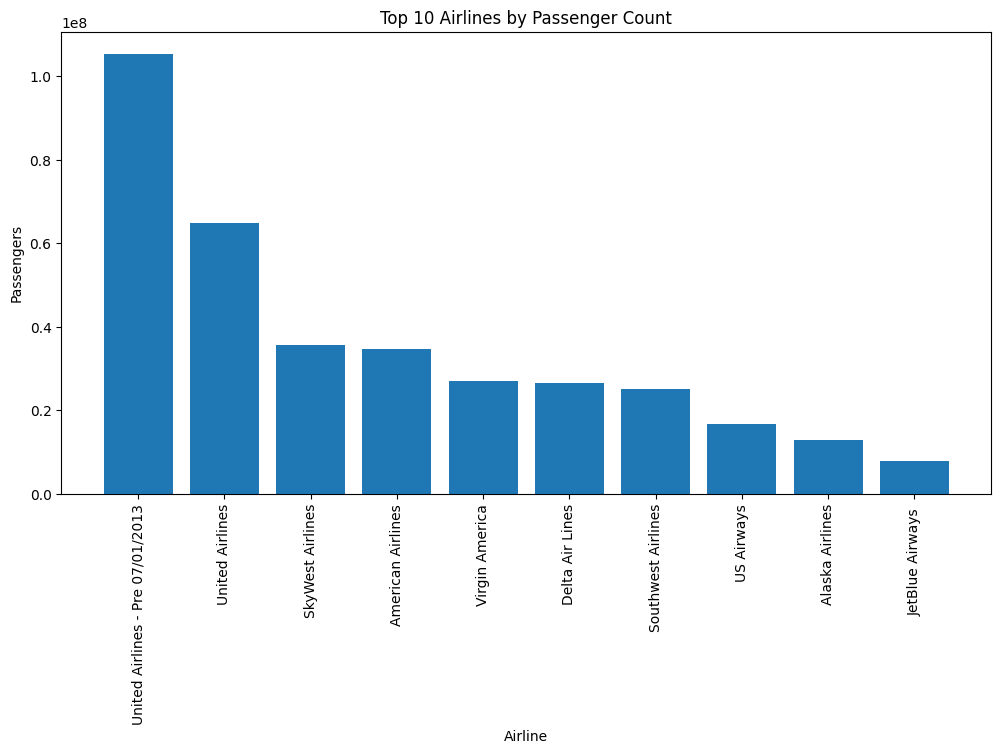

In [13]:
air_pd = top_airlines.limit(10).toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(
    air_pd["Operating Airline"],
    air_pd["Total_Passengers"]
)

plt.xticks(rotation=90)
plt.title("Top 10 Airlines by Passenger Count")
plt.xlabel("Airline")
plt.ylabel("Passengers")
plt.show()


In [14]:
geo = (
    df.groupBy("GEO Summary")
      .agg(sum("Passenger Count").alias("Passengers"))
)

geo.toPandas()

,GEO Summary,Passengers
0,International,100668868
1,Domestic,338136173


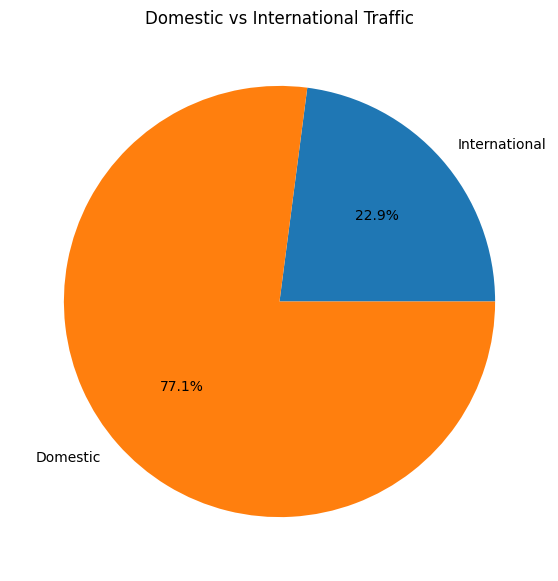

In [15]:
geo_pd = geo.toPandas()

plt.figure(figsize=(7,7))

plt.pie(
    geo_pd["Passengers"],
    labels=geo_pd["GEO Summary"],
    autopct="%1.1f%%"
)

plt.title("Domestic vs International Traffic")
plt.show()


In [16]:
yearly = (
    df.groupBy("Year")
      .agg(sum("Passenger Count").alias("Passengers"))
      .orderBy("Year")
)

yearly.toPandas()

,Year,Passengers
0,2005,17222015
1,2006,33332970
2,2007,35554082
3,2008,37234678
4,2009,37338942
5,2010,39253297
6,2011,40926376
7,2012,44398477
8,2013,44942734
9,2014,47113736


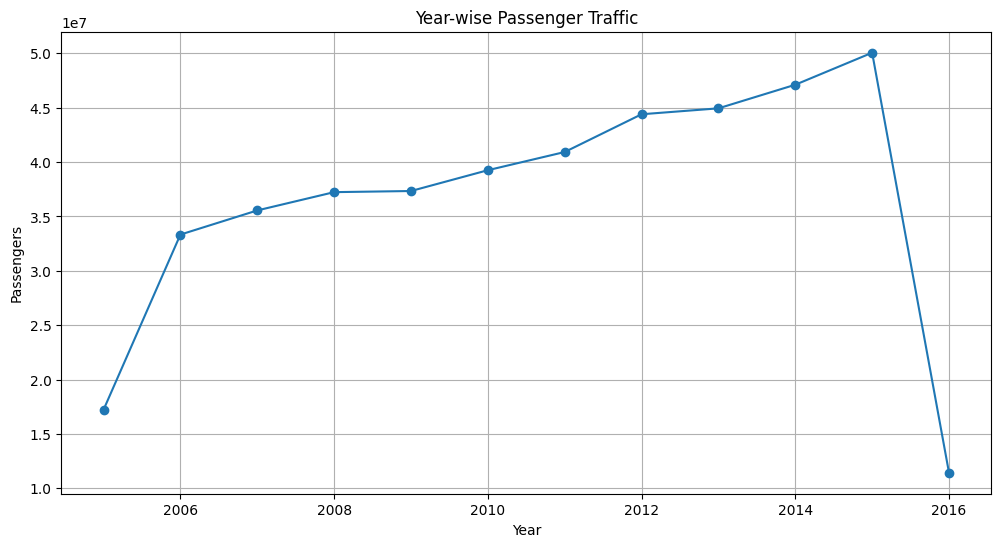

In [17]:
year_pd = yearly.toPandas()

plt.figure(figsize=(12,6))

plt.plot(
    year_pd["Year"],
    year_pd["Passengers"],
    marker="o"
)

plt.title("Year-wise Passenger Traffic")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.grid(True)

plt.show()

In [18]:
region = (
    df.groupBy("GEO Region")
      .agg(sum("Passenger Count").alias("Passengers"))
      .orderBy(desc("Passengers"))
)

region.limit(10).toPandas()

,GEO Region,Passengers
0,US,338136173
1,Asia,43972554
2,Europe,26644611
3,Canada,13865159
4,Mexico,7998587
5,Australia / Oceania,4729341
6,Middle East,1852943
7,Central America,1354932
8,South America,250741


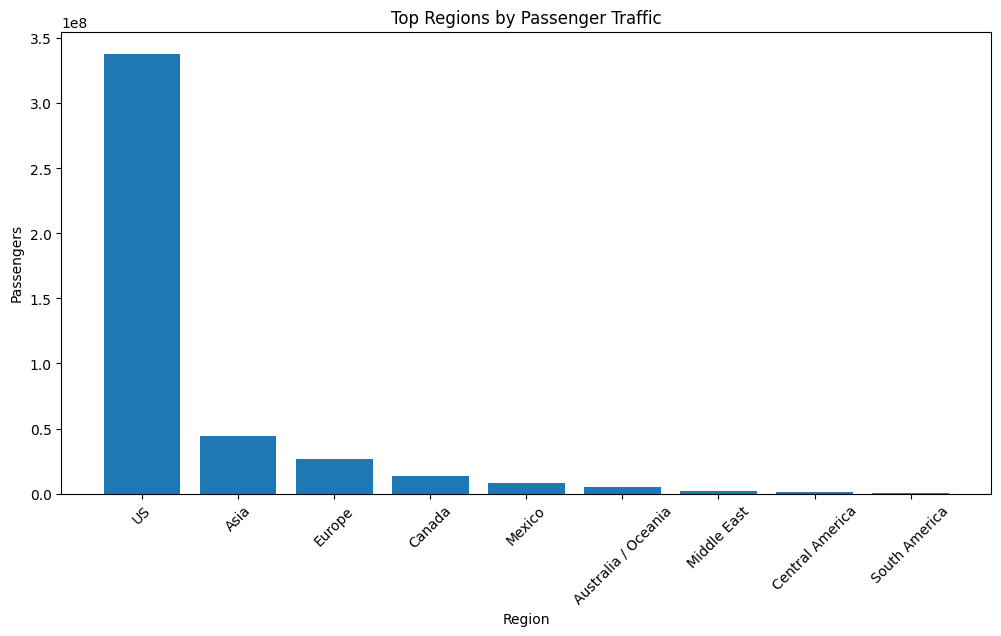

In [19]:
region_pd = region.limit(10).toPandas()

plt.figure(figsize=(12,6))

plt.bar(
    region_pd["GEO Region"],
    region_pd["Passengers"]
)

plt.xticks(rotation=45)
plt.title("Top Regions by Passenger Traffic")
plt.xlabel("Region")
plt.ylabel("Passengers")

plt.show()


,Month,Passengers
0,July,42551298
1,November,34988107
2,February,30444086
3,January,33087428
4,March,36787398
5,October,38390994
6,May,35558223
7,August,42753007
8,April,33104893
9,June,37720965


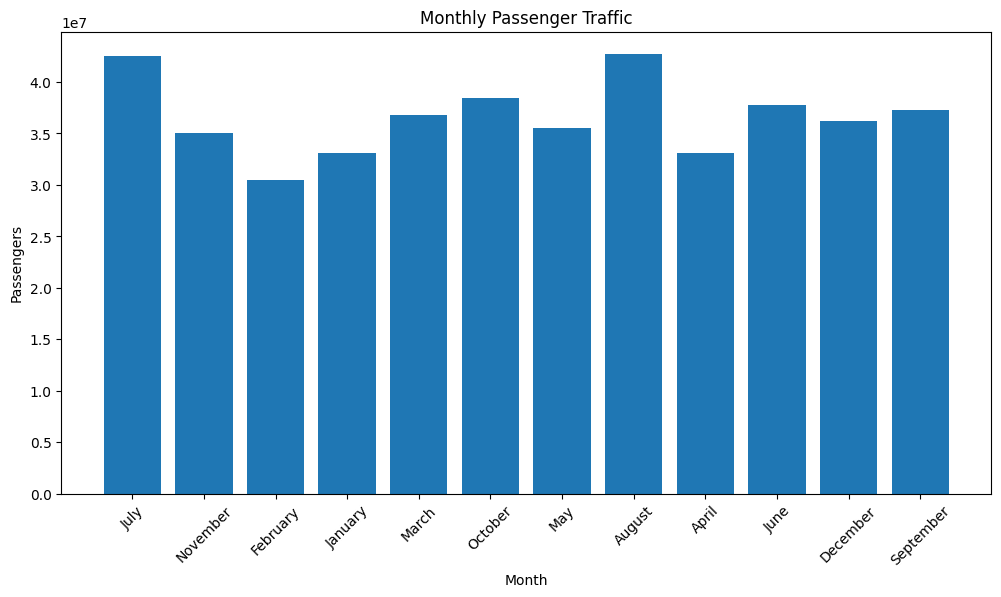

In [20]:
monthly = (
    df.groupBy("Month")
      .agg(sum("Passenger Count").alias("Passengers"))
)

monthly_pd = monthly.toPandas()

display(monthly_pd)

plt.figure(figsize=(12,6))

plt.bar(
    monthly_pd["Month"],
    monthly_pd["Passengers"]
)

plt.xticks(rotation=45)
plt.title("Monthly Passenger Traffic")
plt.xlabel("Month")
plt.ylabel("Passengers")

plt.show()